In [7]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
%matplotlib inline

In [2]:
# geopath = "/data/rong4/yzhuang/Data/ERA5_1deg/geopotential"

# geofiles = [os.path.join(geopath, file) for file in os.listdir(geopath)]

# g = 9.81 # m/s^2

# geofilt = []

# for f in geofiles:
    
#     name = os.path.basename(f)
    
#     ym = name.split('.')[2]  # Extract year-month part from filename
    
#     yr = int(ym[0:4])
    
#     m = int(ym[4:6])

#     if 5 <= m <= 9 and 2001 <= yr <= 2024:
        
#         geofilt.append(f)

# z500 = xr.open_mfdataset(geofilt, combine='by_coords',  chunks={'time': 24})

# z500 = z500.sel(latitude=slice(50, 25), longitude=slice(235, 295))

# z500['time'] = z500['time'] - pd.Timedelta(hours=6)

# z500['z'] = z500['z'] / g

# _0lst_z500 = z500.sel(time=z500.time.dt.hour == 0)

# # _6lst_z500 = z500.sel(time=z500.time.dt.hour == 6)

# # _12lst_z500 = z500.sel(time=z500.time.dt.hour == 12)

# # _18lst_z500 = z500.sel(time=z500.time.dt.hour == 18)

In [10]:
# -----------------------------
# Settings / toggles
# -----------------------------

g = 9.81

WARM_MONTHS = [5, 6, 7, 8, 9]

START_YEAR = 1979

END_YEAR   = 2025

In [11]:
geopath_old = "/data/rong4/yzhuang/Data/ERA5_1deg/geopotential"

geopath_new = os.path.expanduser("~/data/era5sgp/era5_sl_500_geopotential_full_us_2024_and_2025")

LAT_SLICE = slice(50, 25)

OLD_LON_SLICE = slice(235, 295)

NEW_LON_SLICE = slice(-125, -65)

# -----------------------------
# Helpers
# -----------------------------
def standardize_time_level(ds):
    rename_map = {}
    if "valid_time" in ds.coords or "valid_time" in ds.dims:
        rename_map["valid_time"] = "time"
    if "pressure_level" in ds.coords or "pressure_level" in ds.dims:
        rename_map["pressure_level"] = "level"
    if rename_map:
        ds = ds.rename(rename_map)
    return ds

def ensure_lon_convention(ds, target="-180_180"):
    lonmax = float(ds.longitude.max())
    if target == "-180_180" and lonmax > 180:
        ds = ds.assign_coords(
            longitude=(((ds.longitude + 180) % 360) - 180)
        ).sortby("longitude")
    return ds

def process_z500(ds, lon_slice, g=9.81):
    ds = ds.drop_vars("expver", errors="ignore")
    if "expver" in ds.coords:
        ds = ds.reset_coords("expver", drop=True)

    ds = ds.sel(latitude=LAT_SLICE, longitude=lon_slice)

    ds["time"] = ds["time"] - pd.Timedelta(hours=6)

    if "z" not in ds.data_vars:
        raise KeyError(f"Expected variable 'z' not found. Vars: {list(ds.data_vars)}")

    ds["z"] = ds["z"] / g
    ds = ds.sel(time=ds.time.dt.hour == 0)

    ds = ds.drop_vars("expver", errors="ignore")
    if "expver" in ds.coords:
        ds = ds.reset_coords("expver", drop=True)

    return ds

def year_month_from_old_filename(path):
    name = os.path.basename(path)
    ym = name.split(".")[2]
    yr = int(ym[:4])
    mo = int(ym[4:6])
    return yr, mo

# -----------------------------
# OLD monthly files
# -----------------------------
z500_old_0lst = None

if START_YEAR <= 2024:
    geofiles_old = sorted(glob.glob(os.path.join(geopath_old, "*.nc")))
    geofilt_old = []

    for f in geofiles_old:
        yr, mo = year_month_from_old_filename(f)
        if (mo in WARM_MONTHS) and (START_YEAR <= yr <= min(END_YEAR, 2024)):
            geofilt_old.append(f)

    if len(geofilt_old) == 0:
        raise FileNotFoundError("No OLD files matched your year range.")

    z500_old = xr.open_mfdataset(geofilt_old, combine="by_coords", chunks={"time": 24})
    z500_old = standardize_time_level(z500_old)

    if "level" in z500_old.coords:
        z500_old = z500_old.sel(level=500)
    elif "pressure_level" in z500_old.coords:
        z500_old = z500_old.rename({"pressure_level": "level"}).sel(level=500)

    z500_old_0lst = process_z500(z500_old, lon_slice=OLD_LON_SLICE, g=g)

    z500_old_0lst = z500_old_0lst.where(
        (z500_old_0lst.time.dt.month.isin(WARM_MONTHS)) &
        (z500_old_0lst.time.dt.year >= START_YEAR) &
        (z500_old_0lst.time.dt.year <= END_YEAR),
        drop=True
    )

# -----------------------------
# NEW daily files
# -----------------------------
geofiles_new = sorted(glob.glob(os.path.join(geopath_new, "*.nc")))
if len(geofiles_new) == 0:
    raise FileNotFoundError(f"No .nc files found in: {geopath_new}")

z500_new = xr.open_mfdataset(geofiles_new, combine="by_coords", chunks={"valid_time": 24})
z500_new = standardize_time_level(z500_new)

if "level" in z500_new.coords:
    z500_new = z500_new.sel(level=500)

z500_new = ensure_lon_convention(z500_new, target="-180_180")

z500_new_0lst = process_z500(z500_new, lon_slice=NEW_LON_SLICE, g=g)

z500_new_0lst = z500_new_0lst.where(
    (z500_new_0lst.time.dt.month.isin(WARM_MONTHS)) &
    (z500_new_0lst.time.dt.year >= START_YEAR) &
    (z500_new_0lst.time.dt.year <= END_YEAR),
    drop=True
)

# -----------------------------
# Combine + dedupe
# -----------------------------
parts = []
if z500_old_0lst is not None:
    parts.append(z500_old_0lst)
parts.append(z500_new_0lst)

_0lst_z500 = xr.concat(parts, dim="time", join="outer").sortby("time")

_0lst_z500 = _0lst_z500.where(
    (_0lst_z500.time.dt.year >= START_YEAR) &
    (_0lst_z500.time.dt.year <= END_YEAR),
    drop=True
)

t = pd.Index(_0lst_z500.time.values)

dupes = t.duplicated(keep="first")

if dupes.any():
    
    _0lst_z500 = _0lst_z500.isel(time=~xr.DataArray(dupes, dims="time"))

In [16]:
# path = "/home/annierosen16/data/era5sgp/era5_sl_700_and_200_geopotential_full_us/*.nc"

# z700_and_200 = xr.open_mfdataset(path, combine="by_coords")

# z700_and_200['valid_time'] = z700_and_200['valid_time'] - pd.Timedelta(hours=6)

# z700_and_200['z'] = z700_and_200['z'] / g

# _0lst_z700_and_200 = z700_and_200.sel(valid_time=z700_and_200.valid_time.dt.hour == 0)

# _0lst_z700_and_200 = _0lst_z700_and_200.rename({"valid_time": "time"})

# _0lst_z700 = _0lst_z700_and_200.sel(pressure_level=700)

# _0lst_z200 = _0lst_z700_and_200.sel(pressure_level=200)

In [12]:
path = '/home/annierosen16/data/era5sgp/era5_sl_850_geopotential_full_us'

z850_files = sorted(glob.glob(f"{path}/*.nc"))

z850 = xr.open_mfdataset(z850_files, combine="by_coords")

z850['valid_time'] = z850['valid_time'] - pd.Timedelta(hours=6)

z850['z'] = z850['z'] / g

_0lst_z850 = z850.sel(valid_time=z850.valid_time.dt.hour == 0)

_0lst_z850 = _0lst_z850.sel(pressure_level=850)

_0lst_z850 = _0lst_z850.rename({"valid_time": "time"})

### select which pressure level for figures below

In [39]:
geopot = _0lst_z500

title_hpa = 500

### climatological geopotential height
#### note: using average across all warm-season days for every gridpoint (rather than a calendar day average)

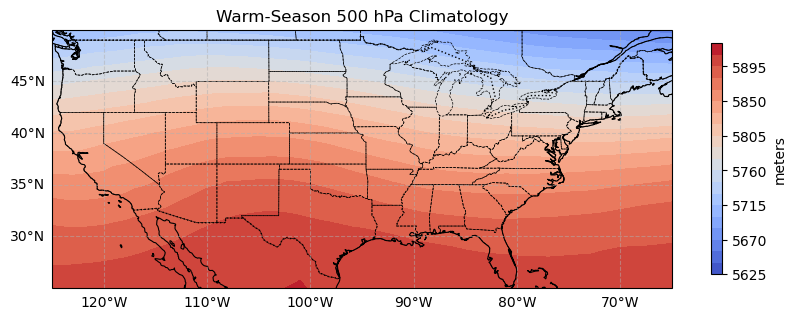

In [40]:
z_mean = geopot["z"].mean(dim="time")

z_std = geopot["z"].std(dim="time")

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

contour = ax.contourf(z_mean["longitude"], z_mean["latitude"], z_mean, 
                       transform=ccrs.PlateCarree(), cmap="coolwarm", levels=20)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

ax.add_feature(cfeature.BORDERS, linestyle=":")

ax.add_feature(cfeature.STATES, linestyle="--", edgecolor="black", linewidth=0.5)  

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

gl.top_labels = False  # Hide top latitude labels

gl.right_labels = False  # Hide right longitude labels

cbar = plt.colorbar(contour, ax=ax, orientation="vertical", shrink=0.5)

cbar.set_label('meters')  # Add the colorbar label here

ax.set_title("Warm-Season {} hPa Climatology".format(title_hpa))

ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())

plt.show()

In [29]:
with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
dryapes = master[master['dryape']==True][['date', 'latitude', 'longitude']]

wetapes = master[master['wetape']==True][['date', 'latitude', 'longitude']]

In [11]:
# category_1_days, category_2_days, category_3_days, category_4_days = [], [], [], []

# threshold_count = 20

# for date in pd.to_datetime(geopot['time'].values):
    
#     date_only = date.date()
    
#     print(date_only)
        
#     dry_count = len(dryapes[pd.to_datetime(dryapes["date"]).dt.date == date_only])
    
#     wet_count = len(wetapes[pd.to_datetime(wetapes["date"]).dt.date == date_only])

#     if dry_count > threshold_count and wet_count == 0:
        
#         category_1_days.append(date)
    
#     elif wet_count > threshold_count and dry_count == 0:
        
#         category_2_days.append(date)
    
#     elif dry_count > threshold_count and wet_count > threshold_count:
        
#         category_3_days.append(date)
    
#     elif dry_count == 0 and wet_count == 0:
        
#         category_4_days.append(date)
    
# category_counts = [
    
#     len(category_1_days),
    
#     len(category_2_days),
    
#     len(category_3_days),
    
#     len(category_4_days),
# ]

1979-05-01
1979-05-02
1979-05-03
1979-05-04
1979-05-05
1979-05-06
1979-05-07
1979-05-08
1979-05-09
1979-05-10
1979-05-11
1979-05-12
1979-05-13
1979-05-14
1979-05-15
1979-05-16
1979-05-17
1979-05-18
1979-05-19
1979-05-20
1979-05-21
1979-05-22
1979-05-23
1979-05-24
1979-05-25
1979-05-26
1979-05-27
1979-05-28
1979-05-29
1979-05-30
1979-05-31
1979-06-01
1979-06-02
1979-06-03
1979-06-04
1979-06-05
1979-06-06
1979-06-07
1979-06-08
1979-06-09
1979-06-10
1979-06-11
1979-06-12
1979-06-13
1979-06-14
1979-06-15
1979-06-16
1979-06-17
1979-06-18
1979-06-19
1979-06-20
1979-06-21
1979-06-22
1979-06-23
1979-06-24
1979-06-25
1979-06-26
1979-06-27
1979-06-28
1979-06-29
1979-06-30
1979-07-01
1979-07-02
1979-07-03
1979-07-04
1979-07-05
1979-07-06
1979-07-07
1979-07-08
1979-07-09
1979-07-10
1979-07-11
1979-07-12
1979-07-13
1979-07-14
1979-07-15
1979-07-16
1979-07-17
1979-07-18
1979-07-19
1979-07-20
1979-07-21
1979-07-22
1979-07-23
1979-07-24
1979-07-25
1979-07-26
1979-07-27
1979-07-28
1979-07-29
1979-07-30

1983-09-12
1983-09-13
1983-09-14
1983-09-15
1983-09-16
1983-09-17
1983-09-18
1983-09-19
1983-09-20
1983-09-21
1983-09-22
1983-09-23
1983-09-24
1983-09-25
1983-09-26
1983-09-27
1983-09-28
1983-09-29
1983-09-30
1984-05-01
1984-05-02
1984-05-03
1984-05-04
1984-05-05
1984-05-06
1984-05-07
1984-05-08
1984-05-09
1984-05-10
1984-05-11
1984-05-12
1984-05-13
1984-05-14
1984-05-15
1984-05-16
1984-05-17
1984-05-18
1984-05-19
1984-05-20
1984-05-21
1984-05-22
1984-05-23
1984-05-24
1984-05-25
1984-05-26
1984-05-27
1984-05-28
1984-05-29
1984-05-30
1984-05-31
1984-06-01
1984-06-02
1984-06-03
1984-06-04
1984-06-05
1984-06-06
1984-06-07
1984-06-08
1984-06-09
1984-06-10
1984-06-11
1984-06-12
1984-06-13
1984-06-14
1984-06-15
1984-06-16
1984-06-17
1984-06-18
1984-06-19
1984-06-20
1984-06-21
1984-06-22
1984-06-23
1984-06-24
1984-06-25
1984-06-26
1984-06-27
1984-06-28
1984-06-29
1984-06-30
1984-07-01
1984-07-02
1984-07-03
1984-07-04
1984-07-05
1984-07-06
1984-07-07
1984-07-08
1984-07-09
1984-07-10
1984-07-11

1988-08-24
1988-08-25
1988-08-26
1988-08-27
1988-08-28
1988-08-29
1988-08-30
1988-08-31
1988-09-01
1988-09-02
1988-09-03
1988-09-04
1988-09-05
1988-09-06
1988-09-07
1988-09-08
1988-09-09
1988-09-10
1988-09-11
1988-09-12
1988-09-13
1988-09-14
1988-09-15
1988-09-16
1988-09-17
1988-09-18
1988-09-19
1988-09-20
1988-09-21
1988-09-22
1988-09-23
1988-09-24
1988-09-25
1988-09-26
1988-09-27
1988-09-28
1988-09-29
1988-09-30
1989-05-01
1989-05-02
1989-05-03
1989-05-04
1989-05-05
1989-05-06
1989-05-07
1989-05-08
1989-05-09
1989-05-10
1989-05-11
1989-05-12
1989-05-13
1989-05-14
1989-05-15
1989-05-16
1989-05-17
1989-05-18
1989-05-19
1989-05-20
1989-05-21
1989-05-22
1989-05-23
1989-05-24
1989-05-25
1989-05-26
1989-05-27
1989-05-28
1989-05-29
1989-05-30
1989-05-31
1989-06-01
1989-06-02
1989-06-03
1989-06-04
1989-06-05
1989-06-06
1989-06-07
1989-06-08
1989-06-09
1989-06-10
1989-06-11
1989-06-12
1989-06-13
1989-06-14
1989-06-15
1989-06-16
1989-06-17
1989-06-18
1989-06-19
1989-06-20
1989-06-21
1989-06-22

1993-08-05
1993-08-06
1993-08-07
1993-08-08
1993-08-09
1993-08-10
1993-08-11
1993-08-12
1993-08-13
1993-08-14
1993-08-15
1993-08-16
1993-08-17
1993-08-18
1993-08-19
1993-08-20
1993-08-21
1993-08-22
1993-08-23
1993-08-24
1993-08-25
1993-08-26
1993-08-27
1993-08-28
1993-08-29
1993-08-30
1993-08-31
1993-09-01
1993-09-02
1993-09-03
1993-09-04
1993-09-05
1993-09-06
1993-09-07
1993-09-08
1993-09-09
1993-09-10
1993-09-11
1993-09-12
1993-09-13
1993-09-14
1993-09-15
1993-09-16
1993-09-17
1993-09-18
1993-09-19
1993-09-20
1993-09-21
1993-09-22
1993-09-23
1993-09-24
1993-09-25
1993-09-26
1993-09-27
1993-09-28
1993-09-29
1993-09-30
1994-05-01
1994-05-02
1994-05-03
1994-05-04
1994-05-05
1994-05-06
1994-05-07
1994-05-08
1994-05-09
1994-05-10
1994-05-11
1994-05-12
1994-05-13
1994-05-14
1994-05-15
1994-05-16
1994-05-17
1994-05-18
1994-05-19
1994-05-20
1994-05-21
1994-05-22
1994-05-23
1994-05-24
1994-05-25
1994-05-26
1994-05-27
1994-05-28
1994-05-29
1994-05-30
1994-05-31
1994-06-01
1994-06-02
1994-06-03

1998-07-16
1998-07-17
1998-07-18
1998-07-19
1998-07-20
1998-07-21
1998-07-22
1998-07-23
1998-07-24
1998-07-25
1998-07-26
1998-07-27
1998-07-28
1998-07-29
1998-07-30
1998-07-31
1998-08-01
1998-08-02
1998-08-03
1998-08-04
1998-08-05
1998-08-06
1998-08-07
1998-08-08
1998-08-09
1998-08-10
1998-08-11
1998-08-12
1998-08-13
1998-08-14
1998-08-15
1998-08-16
1998-08-17
1998-08-18
1998-08-19
1998-08-20
1998-08-21
1998-08-22
1998-08-23
1998-08-24
1998-08-25
1998-08-26
1998-08-27
1998-08-28
1998-08-29
1998-08-30
1998-08-31
1998-09-01
1998-09-02
1998-09-03
1998-09-04
1998-09-05
1998-09-06
1998-09-07
1998-09-08
1998-09-09
1998-09-10
1998-09-11
1998-09-12
1998-09-13
1998-09-14
1998-09-15
1998-09-16
1998-09-17
1998-09-18
1998-09-19
1998-09-20
1998-09-21
1998-09-22
1998-09-23
1998-09-24
1998-09-25
1998-09-26
1998-09-27
1998-09-28
1998-09-29
1998-09-30
1999-05-01
1999-05-02
1999-05-03
1999-05-04
1999-05-05
1999-05-06
1999-05-07
1999-05-08
1999-05-09
1999-05-10
1999-05-11
1999-05-12
1999-05-13
1999-05-14

2003-06-26
2003-06-27
2003-06-28
2003-06-29
2003-06-30
2003-07-01
2003-07-02
2003-07-03
2003-07-04
2003-07-05
2003-07-06
2003-07-07
2003-07-08
2003-07-09
2003-07-10
2003-07-11
2003-07-12
2003-07-13
2003-07-14
2003-07-15
2003-07-16
2003-07-17
2003-07-18
2003-07-19
2003-07-20
2003-07-21
2003-07-22
2003-07-23
2003-07-24
2003-07-25
2003-07-26
2003-07-27
2003-07-28
2003-07-29
2003-07-30
2003-07-31
2003-08-01
2003-08-02
2003-08-03
2003-08-04
2003-08-05
2003-08-06
2003-08-07
2003-08-08
2003-08-09
2003-08-10
2003-08-11
2003-08-12
2003-08-13
2003-08-14
2003-08-15
2003-08-16
2003-08-17
2003-08-18
2003-08-19
2003-08-20
2003-08-21
2003-08-22
2003-08-23
2003-08-24
2003-08-25
2003-08-26
2003-08-27
2003-08-28
2003-08-29
2003-08-30
2003-08-31
2003-09-01
2003-09-02
2003-09-03
2003-09-04
2003-09-05
2003-09-06
2003-09-07
2003-09-08
2003-09-09
2003-09-10
2003-09-11
2003-09-12
2003-09-13
2003-09-14
2003-09-15
2003-09-16
2003-09-17
2003-09-18
2003-09-19
2003-09-20
2003-09-21
2003-09-22
2003-09-23
2003-09-24

2008-06-07
2008-06-08
2008-06-09
2008-06-10
2008-06-11
2008-06-12
2008-06-13
2008-06-14
2008-06-15
2008-06-16
2008-06-17
2008-06-18
2008-06-19
2008-06-20
2008-06-21
2008-06-22
2008-06-23
2008-06-24
2008-06-25
2008-06-26
2008-06-27
2008-06-28
2008-06-29
2008-06-30
2008-07-01
2008-07-02
2008-07-03
2008-07-04
2008-07-05
2008-07-06
2008-07-07
2008-07-08
2008-07-09
2008-07-10
2008-07-11
2008-07-12
2008-07-13
2008-07-14
2008-07-15
2008-07-16
2008-07-17
2008-07-18
2008-07-19
2008-07-20
2008-07-21
2008-07-22
2008-07-23
2008-07-24
2008-07-25
2008-07-26
2008-07-27
2008-07-28
2008-07-29
2008-07-30
2008-07-31
2008-08-01
2008-08-02
2008-08-03
2008-08-04
2008-08-05
2008-08-06
2008-08-07
2008-08-08
2008-08-09
2008-08-10
2008-08-11
2008-08-12
2008-08-13
2008-08-14
2008-08-15
2008-08-16
2008-08-17
2008-08-18
2008-08-19
2008-08-20
2008-08-21
2008-08-22
2008-08-23
2008-08-24
2008-08-25
2008-08-26
2008-08-27
2008-08-28
2008-08-29
2008-08-30
2008-08-31
2008-09-01
2008-09-02
2008-09-03
2008-09-04
2008-09-05

2013-05-18
2013-05-19
2013-05-20
2013-05-21
2013-05-22
2013-05-23
2013-05-24
2013-05-25
2013-05-26
2013-05-27
2013-05-28
2013-05-29
2013-05-30
2013-05-31
2013-06-01
2013-06-02
2013-06-03
2013-06-04
2013-06-05
2013-06-06
2013-06-07
2013-06-08
2013-06-09
2013-06-10
2013-06-11
2013-06-12
2013-06-13
2013-06-14
2013-06-15
2013-06-16
2013-06-17
2013-06-18
2013-06-19
2013-06-20
2013-06-21
2013-06-22
2013-06-23
2013-06-24
2013-06-25
2013-06-26
2013-06-27
2013-06-28
2013-06-29
2013-06-30
2013-07-01
2013-07-02
2013-07-03
2013-07-04
2013-07-05
2013-07-06
2013-07-07
2013-07-08
2013-07-09
2013-07-10
2013-07-11
2013-07-12
2013-07-13
2013-07-14
2013-07-15
2013-07-16
2013-07-17
2013-07-18
2013-07-19
2013-07-20
2013-07-21
2013-07-22
2013-07-23
2013-07-24
2013-07-25
2013-07-26
2013-07-27
2013-07-28
2013-07-29
2013-07-30
2013-07-31
2013-08-01
2013-08-02
2013-08-03
2013-08-04
2013-08-05
2013-08-06
2013-08-07
2013-08-08
2013-08-09
2013-08-10
2013-08-11
2013-08-12
2013-08-13
2013-08-14
2013-08-15
2013-08-16

2017-09-28
2017-09-29
2017-09-30
2018-05-01
2018-05-02
2018-05-03
2018-05-04
2018-05-05
2018-05-06
2018-05-07
2018-05-08
2018-05-09
2018-05-10
2018-05-11
2018-05-12
2018-05-13
2018-05-14
2018-05-15
2018-05-16
2018-05-17
2018-05-18
2018-05-19
2018-05-20
2018-05-21
2018-05-22
2018-05-23
2018-05-24
2018-05-25
2018-05-26
2018-05-27
2018-05-28
2018-05-29
2018-05-30
2018-05-31
2018-06-01
2018-06-02
2018-06-03
2018-06-04
2018-06-05
2018-06-06
2018-06-07
2018-06-08
2018-06-09
2018-06-10
2018-06-11
2018-06-12
2018-06-13
2018-06-14
2018-06-15
2018-06-16
2018-06-17
2018-06-18
2018-06-19
2018-06-20
2018-06-21
2018-06-22
2018-06-23
2018-06-24
2018-06-25
2018-06-26
2018-06-27
2018-06-28
2018-06-29
2018-06-30
2018-07-01
2018-07-02
2018-07-03
2018-07-04
2018-07-05
2018-07-06
2018-07-07
2018-07-08
2018-07-09
2018-07-10
2018-07-11
2018-07-12
2018-07-13
2018-07-14
2018-07-15
2018-07-16
2018-07-17
2018-07-18
2018-07-19
2018-07-20
2018-07-21
2018-07-22
2018-07-23
2018-07-24
2018-07-25
2018-07-26
2018-07-27

2022-09-09
2022-09-10
2022-09-11
2022-09-12
2022-09-13
2022-09-14
2022-09-15
2022-09-16
2022-09-17
2022-09-18
2022-09-19
2022-09-20
2022-09-21
2022-09-22
2022-09-23
2022-09-24
2022-09-25
2022-09-26
2022-09-27
2022-09-28
2022-09-29
2022-09-30
2023-05-01
2023-05-02
2023-05-03
2023-05-04
2023-05-05
2023-05-06
2023-05-07
2023-05-08
2023-05-09
2023-05-10
2023-05-11
2023-05-12
2023-05-13
2023-05-14
2023-05-15
2023-05-16
2023-05-17
2023-05-18
2023-05-19
2023-05-20
2023-05-21
2023-05-22
2023-05-23
2023-05-24
2023-05-25
2023-05-26
2023-05-27
2023-05-28
2023-05-29
2023-05-30
2023-05-31
2023-06-01
2023-06-02
2023-06-03
2023-06-04
2023-06-05
2023-06-06
2023-06-07
2023-06-08
2023-06-09
2023-06-10
2023-06-11
2023-06-12
2023-06-13
2023-06-14
2023-06-15
2023-06-16
2023-06-17
2023-06-18
2023-06-19
2023-06-20
2023-06-21
2023-06-22
2023-06-23
2023-06-24
2023-06-25
2023-06-26
2023-06-27
2023-06-28
2023-06-29
2023-06-30
2023-07-01
2023-07-02
2023-07-03
2023-07-04
2023-07-05
2023-07-06
2023-07-07
2023-07-08

In [12]:
# target_date = np.datetime64("2011-07-30")

# category_1_days = [d for d in category_1_days if d != target_date]

# category_2_days = [d for d in category_2_days if d != target_date]

# category_3_days = [d for d in category_3_days if d != target_date]

# category_4_days = [d for d in category_4_days if d != target_date]

# print(len(category_1_days), len(category_2_days), len(category_3_days), len(category_4_days))

894 407 1082 419


In [13]:
# out_path = "/home/annierosen16/category_days_1979_2025.pkl"

# with open(out_path, "wb") as f:
    
#     pickle.dump({
        
#         "category_1": category_1_days,
        
#         "category_2": category_2_days,
        
#         "category_3": category_3_days,
        
#         "category_4": category_4_days,
    
#     }, f)

# print(f"Saved category days to {out_path}")

Saved category days to /home/annierosen16/category_days_1979_2025.pkl


In [41]:
## read them back in 

in_path = "/home/annierosen16/category_days_1979_2025.pkl"

with open(in_path, "rb") as f:
    
    data = pickle.load(f)

category_1_days = data["category_1"]

category_2_days = data["category_2"]

category_3_days = data["category_3"]

category_4_days = data["category_4"]

category_counts = [
    
    len(category_1_days),
    
    len(category_2_days),
    
    len(category_3_days),
    
    len(category_4_days)]

print(category_counts)

[894, 407, 1082, 419]


In [43]:
categories = {
    
    ">20 Dry APEs & 0 Wet APEs": category_1_days,
    
    ">20 Wet APEs & 0 Dry APEs": category_2_days,

}

selected_dates_dict = {cat: [np.datetime64(date) for date in dates] for cat, dates in categories.items()}

# load geopotential mean and standard deviation

z_mean = geopot["z"].mean(dim="time")

z_std = geopot["z"].std(dim="time")

composite_anomalies = {}

composite_heights = {}

for cat, selected_dates in selected_dates_dict.items():
    
    z_selected = geopot["z"].sel(time=selected_dates).compute()  # load all at once
    
    z_anomalies = (z_selected - z_mean) / z_std  # Compute anomalies
    
    composite_anomalies[cat] = z_anomalies.mean(dim="time")  # Compute mean anomaly
    
    composite_heights[cat] = z_selected.mean(dim="time")  

abs_max = max(max(abs(comp.min().compute()), abs(comp.max().compute())) for comp in composite_anomalies.values())

vmin, vmax = -abs_max, abs_max

### figure for composite anomalies

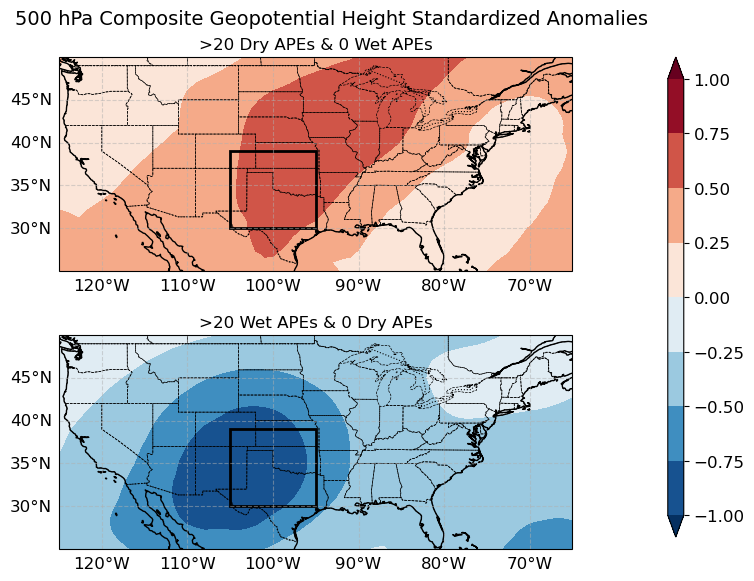

In [44]:
# Define levels from -1 to 1 in 0.25 increments

levels = np.arange(-1.0, 1.01, 0.25)  # .01 to include 1.0

# Your plot setup remains the same...
fig, axes = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, (cat, comp_anomaly) in zip(axes, composite_anomalies.items()):
    
    contour = ax.contourf(
        geopot["longitude"], geopot["latitude"], comp_anomaly, 
        transform=ccrs.PlateCarree(), cmap="RdBu_r", levels=levels, extend="both")
    
    # Map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    ax.add_feature(cfeature.STATES, linestyle="--", edgecolor="black", linewidth=0.5)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    # Plot title
    ax.set_title(f"{cat}", fontsize=12)

    # SGP region box
    sgp_lon_min, sgp_lon_max = -105, -95
    sgp_lat_min, sgp_lat_max = 30, 39
    box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                    linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
    ax.add_patch(box)
    
    ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])

cbar = fig.colorbar(contour, cax=cbar_ax, ticks=levels)

cbar.ax.tick_params(labelsize=12)

# super title

fig.suptitle(f"{title_hpa} hPa Composite Geopotential Height Standardized Anomalies", fontsize=14)

# Layout spacing
plt.subplots_adjust(left=0.08, right=0.88, bottom=0.08, top=0.90, hspace=0.3)

plt.show()


### figure for composite heights

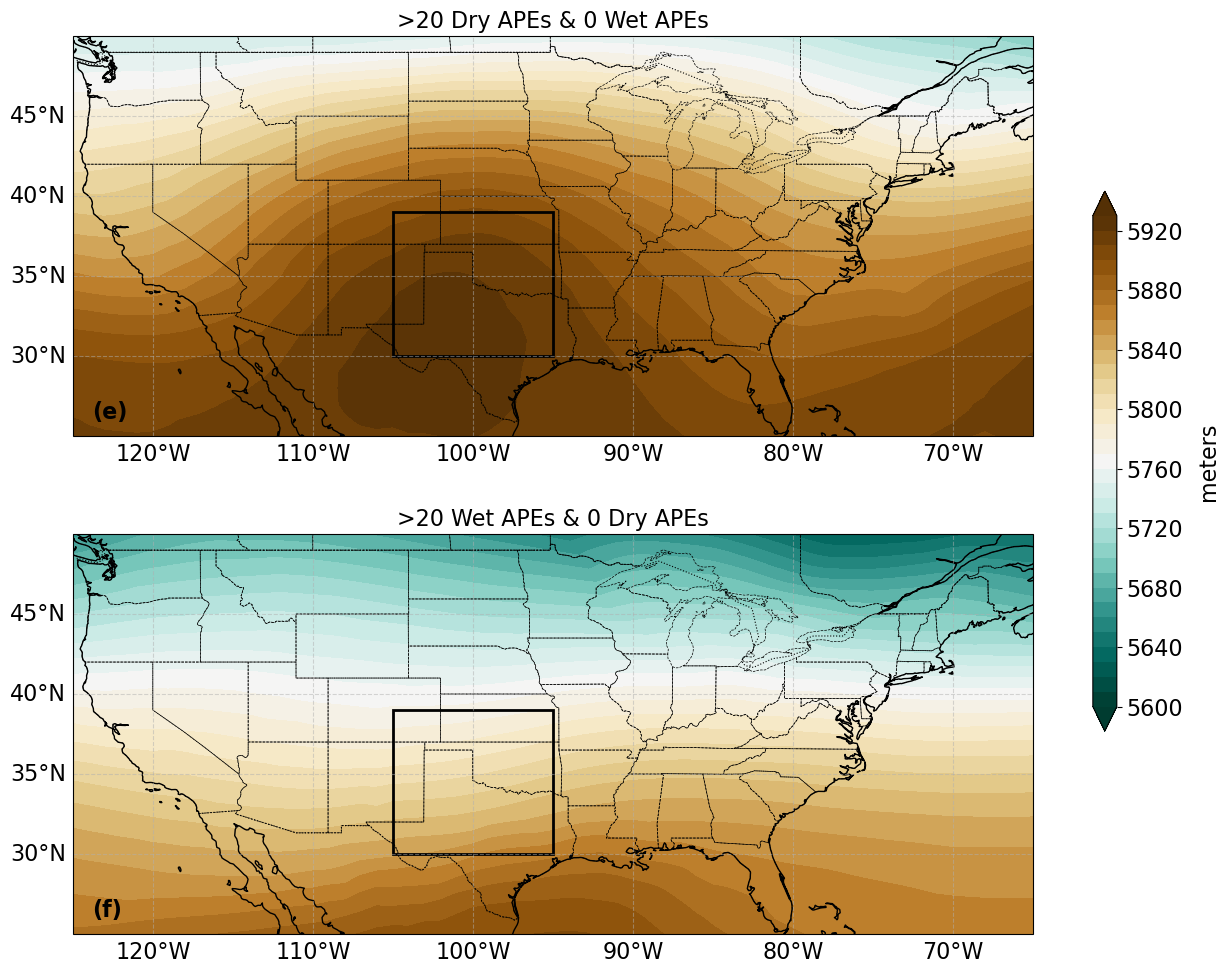

In [46]:
# Compute min/max from all composites

vmin = min(comp.min().compute() for comp in composite_heights.values())

vmax = max(comp.max().compute() for comp in composite_heights.values())

# Round vmax up to the nearest 10 for clean ticks
vmax = np.ceil(vmax / 10) * 10

vmin = np.floor(vmin / 10) * 10  # optional: round down vmin to nearest 10

# Define levels with spacing of 10 units
levels = np.arange(vmin, vmax + 1, 10)

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, (cat, comp_height) in zip(axes, composite_heights.items()):
    
    contour = ax.contourf(
        
        geopot["longitude"], geopot["latitude"], comp_height, 
        
        transform=ccrs.PlateCarree(), cmap="BrBG_r", levels=levels, extend="both")
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    
    ax.add_feature(cfeature.STATES, linestyle="--", edgecolor="black", linewidth=0.5)

    # Gridlines and labels with larger font
    
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    
    gl.top_labels = False
    
    gl.right_labels = False
    
    gl.xlabel_style = {"size": 16}
    
    gl.ylabel_style = {"size": 16}

    # Title for each plot
    ax.set_title(f"{cat}", fontsize=16)
    
    sgp_lon_min, sgp_lon_max = -105, -95
    
    sgp_lat_min, sgp_lat_max = 30, 39

    box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())

    ax.add_patch(box)
    
    ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())

# Larger colorbar placement
cbar_ax = fig.add_axes([0.93, 0.32, 0.02, 0.45])
cbar = fig.colorbar(contour, cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label('meters', fontsize=16, labelpad=10, rotation=90)

# plt.subplots_adjust(left=0.08, right=0.88, top=0.92, bottom=0.25, hspace=0.35)

# fig.savefig("../test.png", dpi=300, bbox_inches='tight')

import textwrap

n_dry = len(category_1_days)
n_wet = len(category_2_days)

raw_caption = (
    r'$\bf{Figure\ 6.}$ '
    f'Composite {title_hpa} hPa geopotential height for days falling under '
    f'(c) dry and (d) wet APE "preferred" regimes. '
    f'A dry (wet) APE "preferred" regime is defined as days in which > 20 dry (wet) APEs '
    f'occurred while 0 wet (dry) APEs occurred. '
    f'The number of days used is n = {n_dry} days for the dry regime and '
    f'n = {n_wet} days for the wet regime. '
    'The black box denotes the Southern Great Plains domain used in this study.'
)
plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.93,
    bottom=0.12,   # ← increase bottom margin to give caption room
    hspace=0.05    # ← tighter gap between the two panels
)

# Wider caption text

caption = textwrap.fill(raw_caption, width=130)

# Move caption closer to figure
# fig.text(
#     0.5,
#     0.01,          # ← sits within the bottom margin, won't overlap panels
#     caption,
#     ha='center',
#     va='bottom',
#     fontsize=14
# )

# ----------------------------
# Panel labels (bottom-left)
# ----------------------------
panel_labels = ['(e)', '(f)']  # top panel, bottom panel

for ax, lab in zip(axes, panel_labels):
    
    ax.text(
        
        0.02, 0.03,          # x, y in axis coordinates
        lab,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontweight='bold',
        fontsize=16
    )
    
fig.savefig("/home/annierosen16/500hpa_geopotential.png", dpi=300, bbox_inches="tight")

plt.show()